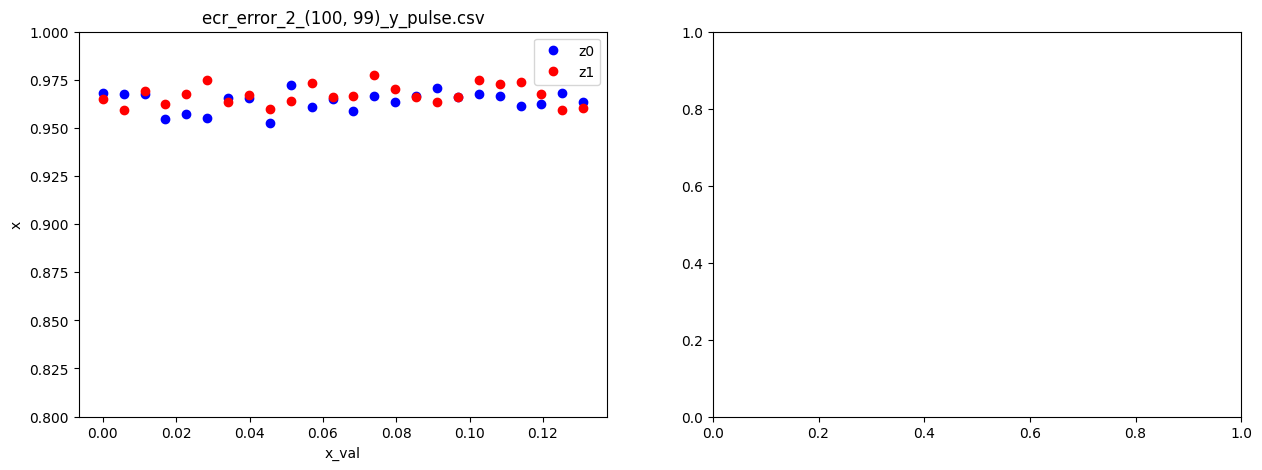

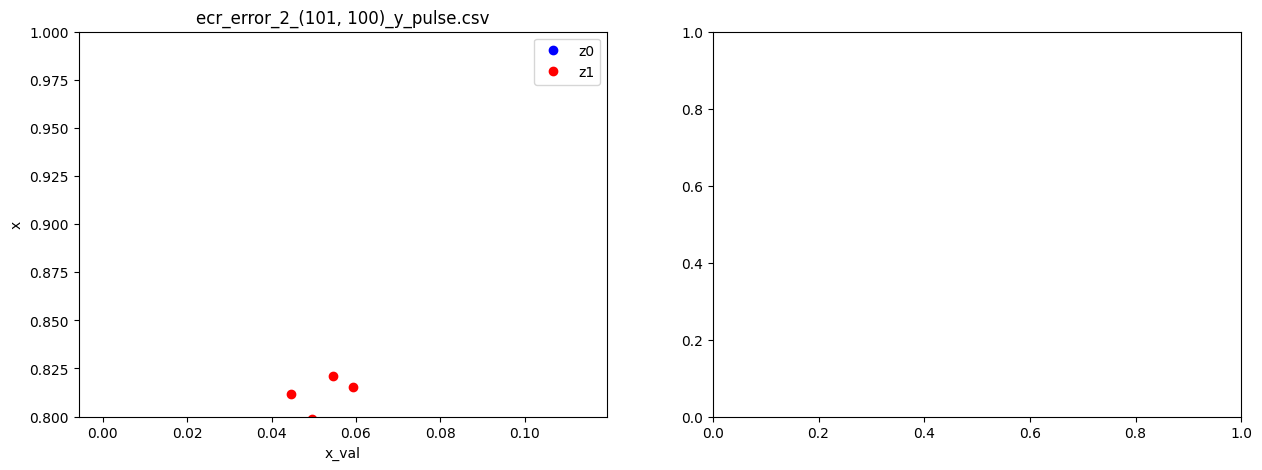

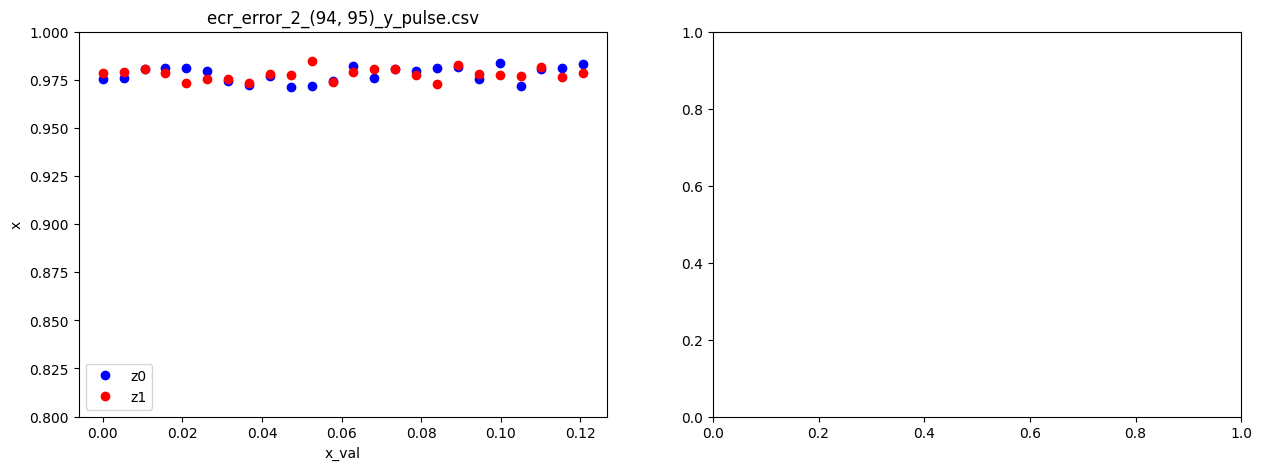

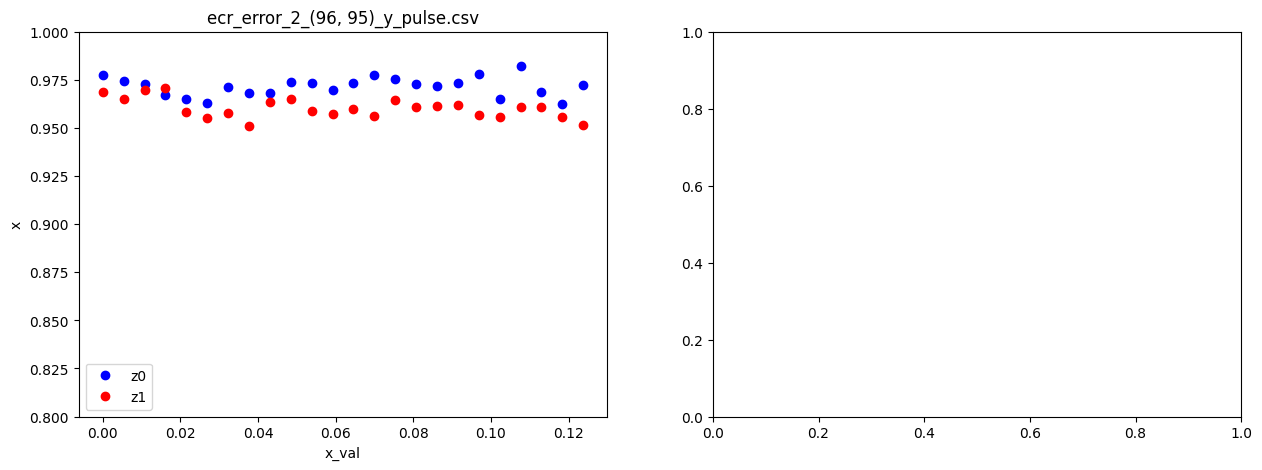

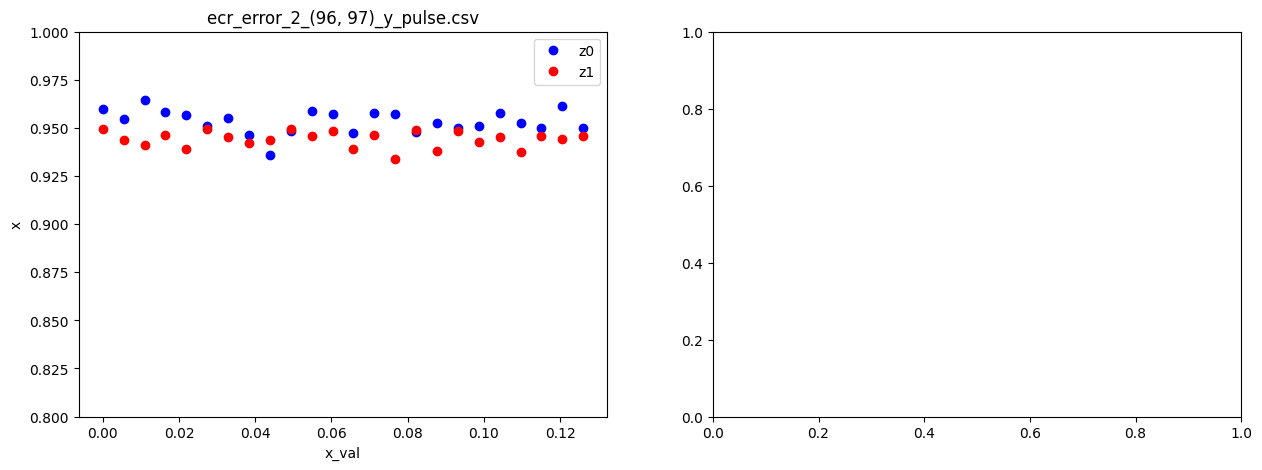

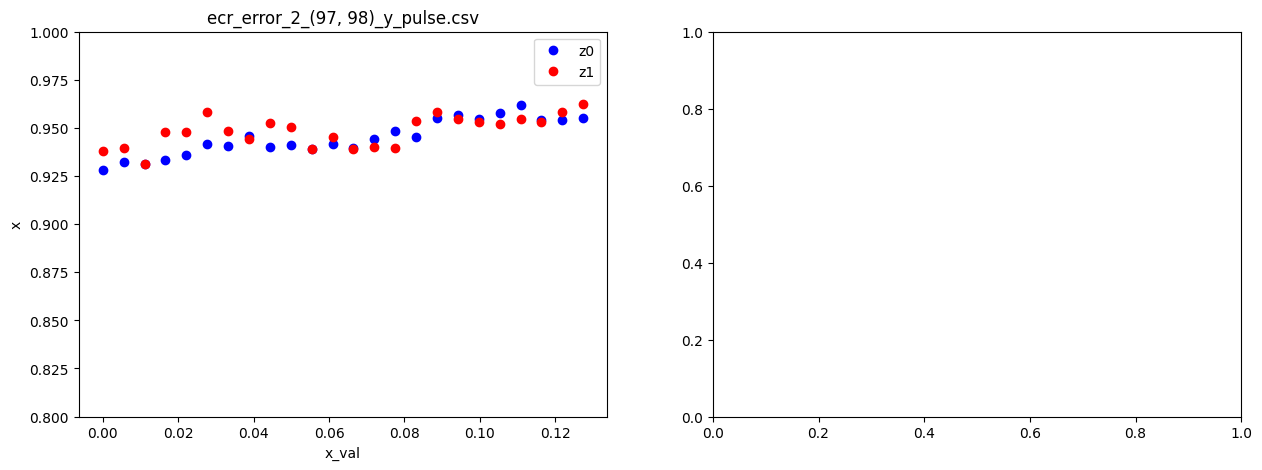

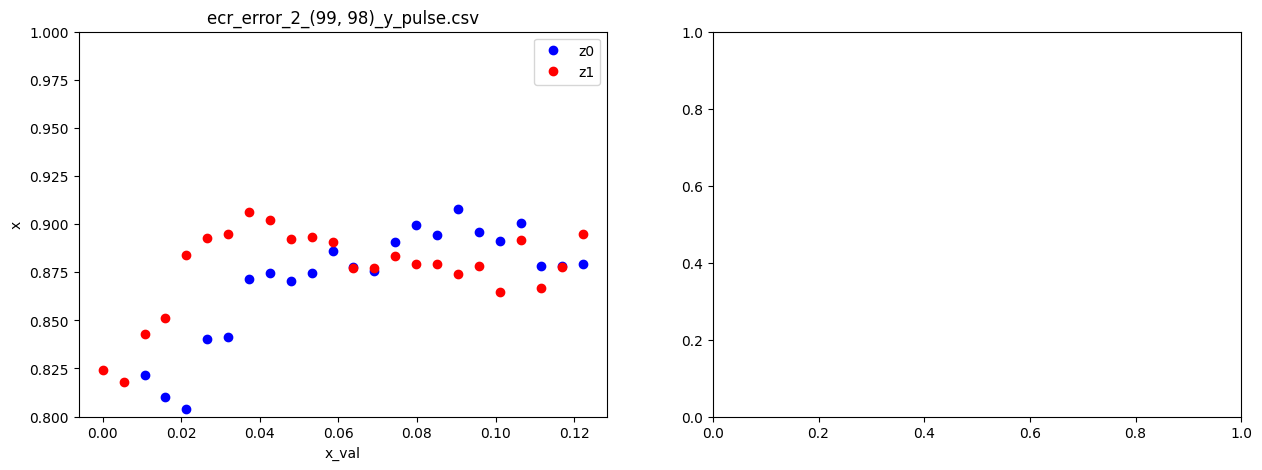

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
directory =  'ibm_osaka'
# 현재 디렉토리 내의 조건에 맞는 파일 목록 가져오기
files_ends_with_csv = [f for f in os.listdir(directory) if os.path.isfile(f) and f.startswith('ecr_2dt')]
files_starts_with_ecr = [f for f in os.listdir(directory) if f.startswith('ecr_error')]

# 서브플롯의 개수 설정

meas_basis = 'z'
# 첫 번째 subplot: ).csv로 끝나는 파일들
for index,file in enumerate(files_starts_with_ecr):
    # CSV 파일 읽기
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    df = pd.read_csv(os.path.join(directory, file))
    # 데이터 플롯
    axs[0].plot(df['xval'], df[f'{meas_basis}0'],'bo', label=f'{meas_basis}0')
    axs[0].plot(df['xval'], df[f'{meas_basis}1'],'ro', label=f'{meas_basis}1')
    # 첫 번째 subplot 설정
    axs[0].set_title(file)
    axs[0].set_xlabel('x_val')
    axs[0].set_ylabel('x')
    axs[0].legend()
    if max(df[f'{meas_basis}0'])>0.5:
        z = True
    else:
        z = False
    if z:
        axs[0].set_ylim(0.8, 1)
    else:
        axs[0].set_ylim(-0.1, 0.2)










In [1]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = 'ibm_kyoto'

# Get a list of all CSV files in the specified directory
csv_files = [file for file in os.listdir(directory) if file.endswith('.csv') and file.startswith('ecr_error_')]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r'ecr_error_\d+_\((\d+),\s*(\d+)\)_y_pulse.csv')

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))
        
        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]
        
        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[(abs(filtered_df['x1']) + abs(filtered_df['x0'])).idxmin()]
        print((abs(filtered_df['x1']) + abs(filtered_df['x0'])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row['xval']
        
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval

# Print the results
print(X_dict)



0.008
0.0209999999999999
0.0104999999999999
0.015
0.006999999999999999
0.0169999999999998
0.0124999999999999
{(79, 78): 0.0991539201061559, (80, 79): 0.1058355238674334, (81, 80): 0.0938595551373362, (82, 81): 0.1226071009703679, (82, 83): 0.1015512610356359, (84, 83): 0.1169194911498452, (84, 85): 0.121923192422829}


In [2]:
from functions.Train_ZNE import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes,EfficientSU2

service = QiskitRuntimeService(channel='ibm_quantum',
    instance='ibm-q-skku/skku/skku-students',
    token = '06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854')
backend = service.backend('ibm_kyoto')


config = {'backend':backend,'x_amp_dict':X_dict,'error_stretch':1.,'ecr_stretch':1.,'l':0}

In [3]:
temp_class = train_ZNE(20,**config)

In [4]:
class_id = 'eed97a17-dcbf-4620-8a71-d4a057bc2e3b'
temp_class.load_data(class_id)

In [31]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np
from qiskit.compiler import transpile
from qiskit_ibm_runtime.options import TwirlingOptions
from qiskit.quantum_info import SparsePauliOp
import uuid
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
def create_trotterized_ising_model_circuit(num_qubits, trotter_steps, time):
    """
    Trotterization을 사용하여 Ising 모델의 양자 서킷을 생성합니다.
    각 Rz 게이트의 파라미터는 Qiskit Parameter로 동적으로 설정됩니다.

    Parameters:
    - num_qubits: 큐비트의 수
    - trotter_steps: Trotterization 단계 수
    - time: 진화 시간

    Returns:
    - QuantumCircuit: 생성된 양자 서킷
    - dict: 서킷 파라미터 사전
    """
    qc = QuantumCircuit(num_qubits)
    delta_t = 1

    # 파라미터 설정
    h_params = [Parameter(f'h_{i}') for i in range(num_qubits)]
    J_params = [[Parameter(f'J_{i}_{j}') for j in range(num_qubits)] for i in range(num_qubits)]

    for _ in range(trotter_steps):
        # 자기 상호작용 항목 추가
        
        for i in range(num_qubits):
            qc.rx(2 * h_params[i] * delta_t, i)

        # 스핀 간 상호작용 항목 추가
        for i in range(num_qubits-1):
            if J_params[i][i+1] != 0:
                qc.cx(i, i+1)
                qc.rz(2 * J_params[i][i+1] * delta_t, i+1)
                qc.cx(i, i+1)

    return qc, h_params, J_params


# ECR 게이트를 제거하는 함수
def remove_ecr_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for instr, qargs, cargs in circuit.data:
        if instr.name != 'ecr':
            new_circuit.append(instr, qargs, cargs)
    return new_circuit

# 파라미터 설정
trotter_steps = 3  # Trotterization 단계 수
time = 1.0  # 진화 시간
num_qubits = 8
init_p  =['I' for i in range(num_qubits)]
p_list = []
for i in range(num_qubits):
    temp = init_p.copy()
    temp[i] = 'Z'
    p_list.append(''.join(temp))


hamiltonian = SparsePauliOp.from_list([(p_list[i],1) for i in range(num_qubits)])
trotterized_ising_circuit, h_params, J_params = create_trotterized_ising_model_circuit(8, trotter_steps, time)

In [32]:
ZNE_temp = ZNE(trotterized_ising_circuit,hamiltonian,**config)

In [33]:
ZNE_temp.make_data()

KeyboardInterrupt: 

In [5]:
result = temp_class.get_data()

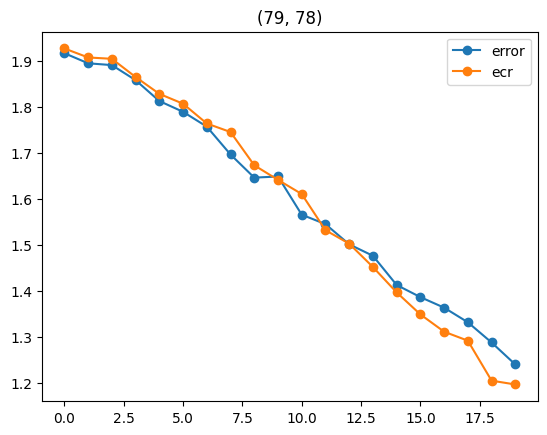

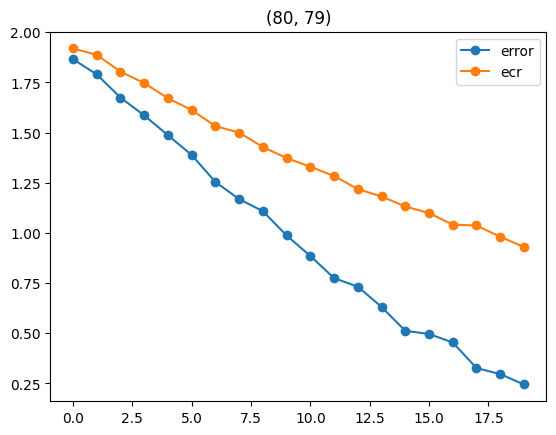

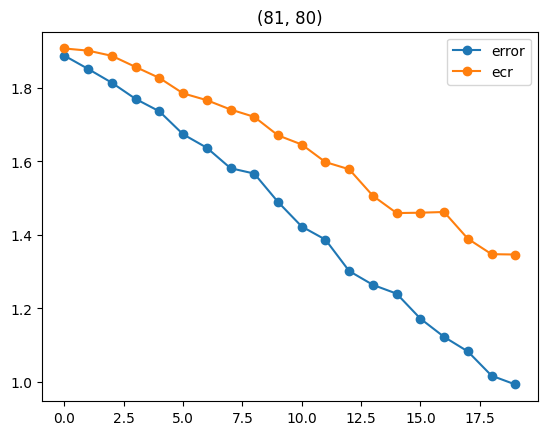

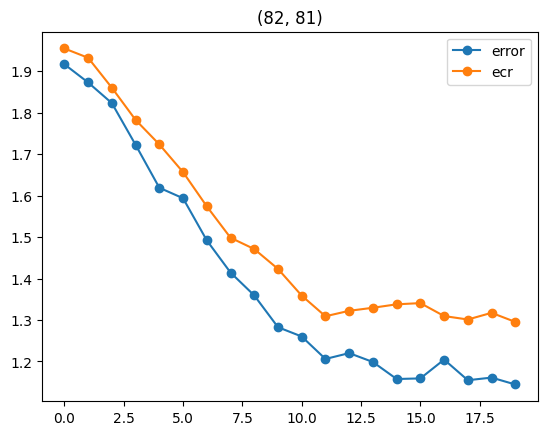

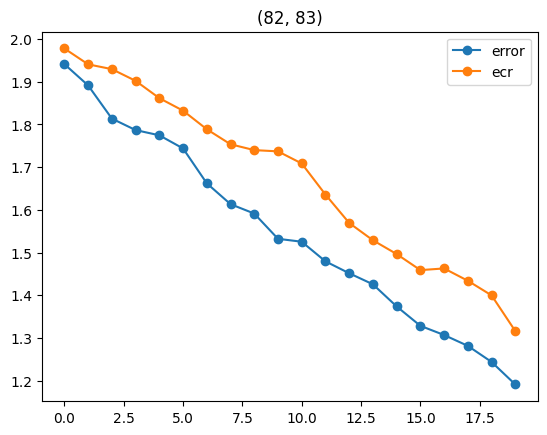

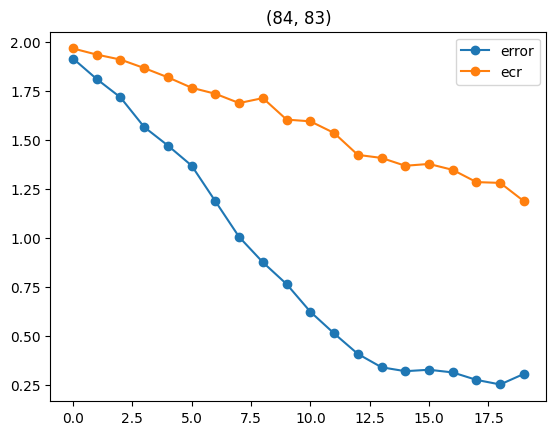

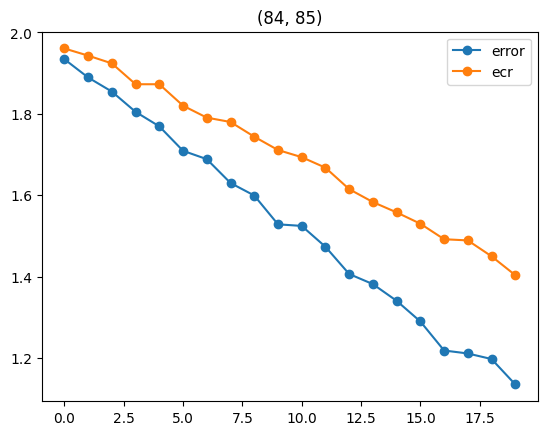

In [29]:
from matplotlib import pyplot as plt
for key in X_dict.keys():
    data_error = result[f'{list(key)}_even']
    data_ecr = result[f'{list(key)}_ecr']
    plt.figure()
    plt.title(key)
    plt.plot(data_error,'o-',label='error')
    plt.plot(data_ecr,'o-',label='ecr')
    plt.legend()
    plt.show()

In [41]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = 'ibm_osaka'

# Get a list of all CSV files in the specified directory
csv_files = [file for file in os.listdir(directory) if file.endswith('.csv') and file.startswith('ecr_error_')]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r'ecr_error_\d+_\((\d+),\s*(\d+)\)_y_pulse.csv')

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))
        
        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]
        
        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[(abs(filtered_df['x1']) + abs(filtered_df['x0'])).idxmin()]
        print((abs(filtered_df['x1']) + abs(filtered_df['x0'])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row['xval']
        
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval
X_dict

0.017999999999999898
0.1164999999999998
0.004
0.0035
0.0114999999999998
0.0144999999999999
0.0289999999999999


{(100, 99): 0.09679704473258,
 (101, 100): 0.1089248530820584,
 (94, 95): 0.0839491578128234,
 (96, 95): 0.0860918485934419,
 (96, 97): 0.082204261452346,
 (97, 98): 0.0553878640961855,
 (99, 98): 0.1010473869804838}

In [44]:
from functions.Train_ZNE import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes,EfficientSU2

service = QiskitRuntimeService(channel='ibm_quantum',
    instance='ibm-q-skku/skku/skku-students',
    token = '06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854')
backend = service.backend('ibm_osaka')


config = {'backend':backend,'x_amp_dict':X_dict,'error_stretch':1.,'ecr_stretch':1.,'l':0}

In [45]:
temp_class = train_ZNE(20,**config)
temp_class.run()

In [46]:
ZNE_temp = ZNE(trotterized_ising_circuit,hamiltonian,**config)
ZNE_temp.make_data()

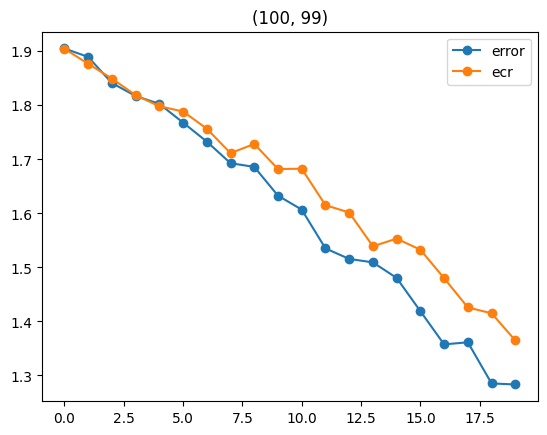

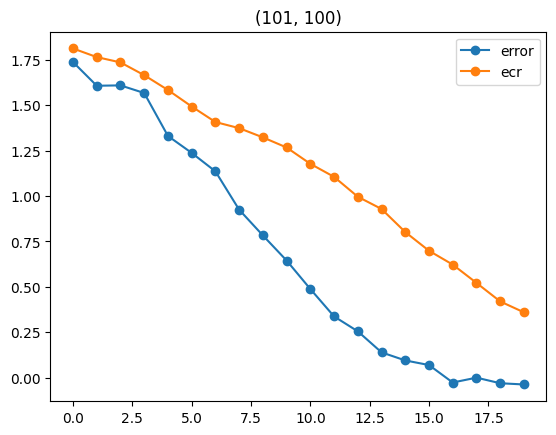

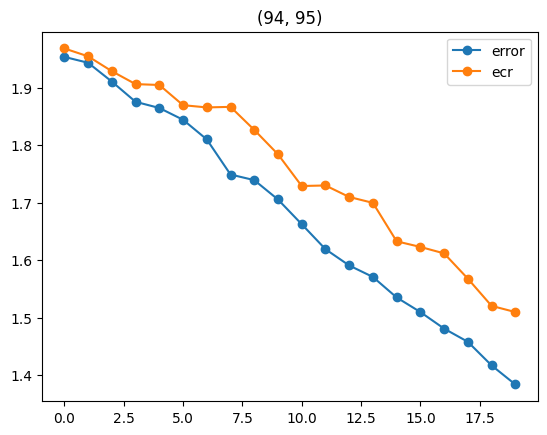

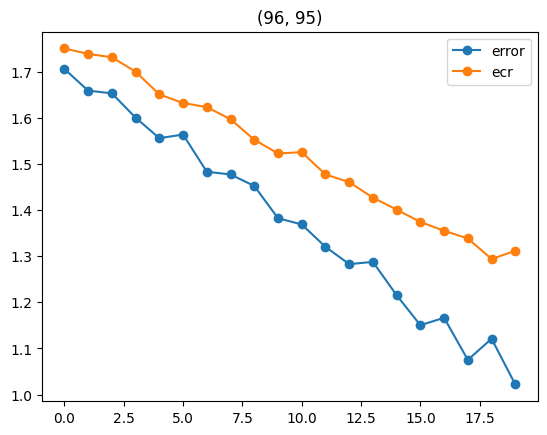

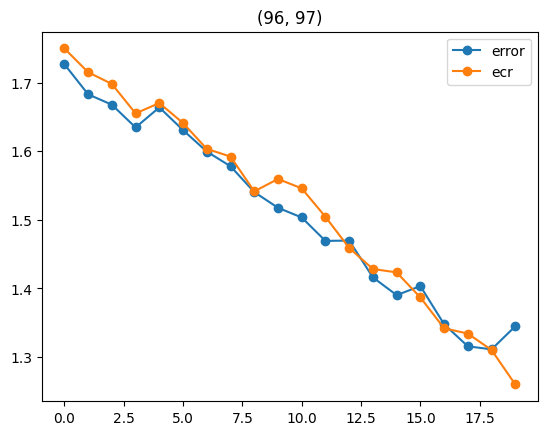

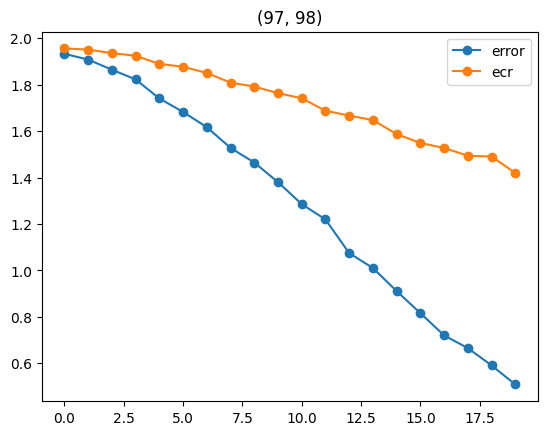

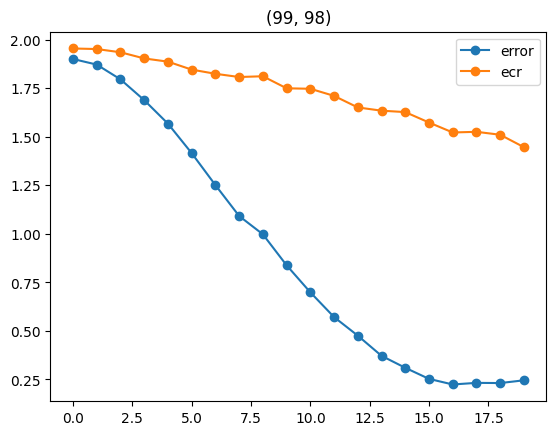

In [47]:
result = temp_class.get_data()
from matplotlib import pyplot as plt
for key in X_dict.keys():
    data_error = result[f'{list(key)}_even']
    data_ecr = result[f'{list(key)}_ecr']
    plt.figure()
    plt.title(key)
    plt.plot(data_error,'o-',label='error')
    plt.plot(data_ecr,'o-',label='ecr')
    plt.legend()
    plt.show()